# 🛒 Supermarket Sales — Data Cleaning, Analysis & Visualization
### Assignment: Day 20 | Dataset: supermarket_sales.csv
---
**Topics Covered:**
- Data Cleaning (missing values, duplicates, type conversion)
- Exploratory Data Analysis (univariate & bivariate)
- Outlier Detection & Treatment (Z-score & IQR)
- Pandas Visualizations (Area, Bar, Line, Scatter, KDE, Box, Hexbin, Pie)
- Seaborn Visualizations (Dist, KDE, Rug, Joint, Pair, Factor, Box, Violin, Strip, Swarm, Bar, Count, Heatmap)


## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats


---
## 1. Load & Inspect Data


In [ ]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Update path if needed
df = pd.read_csv('supermarket_sales -.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())


Shape: (1000, 17)

Column names: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


<>:3: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:3: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\TECHNIFI\AppData\Local\Temp\ipykernel_23892\2256701324.py:3: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  df = pd.read_csv('D:\Rough Programming\Python Programming\supermarket_sales -.csv')


In [3]:
# First 5 rows
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
# Dataset info — dtypes, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [5]:
# Statistical summary of numeric columns
df.describe().round(2)


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


---
## 2. Data Cleaning

### 2.1 Check Missing Values


In [6]:
# Check for missing values in every column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing values per column:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Total missing values: 0


### 2.2 Check & Remove Duplicates

In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows: 0
Shape after removing duplicates: (1000, 17)


### 2.3 Fix Data Types — Date & Time

In [8]:
# Convert Date from string to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert Time from string to datetime, then extract hour
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')
df['Hour']      = df['Time'].dt.hour
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

print("Date range:", df['Date'].min(), "→", df['Date'].max())
print("Hour range:", df['Hour'].min(), "→", df['Hour'].max())


Date range: 2019-01-01 00:00:00 → 2019-03-30 00:00:00
Hour range: 10 → 20


### 2.4 Standardise Text Columns

In [9]:
text_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("Unique values after cleaning:")
for col in text_cols:
    print(f"  {col}: {df[col].unique().tolist()}")


Unique values after cleaning:
  Branch: ['A', 'C', 'B']
  City: ['Yangon', 'Naypyitaw', 'Mandalay']
  Customer type: ['Member', 'Normal']
  Gender: ['Female', 'Male']
  Product line: ['Health And Beauty', 'Electronic Accessories', 'Home And Lifestyle', 'Sports And Travel', 'Food And Beverages', 'Fashion Accessories']
  Payment: ['Ewallet', 'Cash', 'Credit Card']


### 2.5 Final Cleaned Dataset

In [10]:
print("Final shape:", df.shape)
print("\nData types:")
print(df.dtypes)


Final shape: (1000, 20)

Data types:
Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
Hour                                int32
Month                               int32
DayOfWeek                          object
dtype: object


In [11]:
df.head(3)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,Month,DayOfWeek
0,750-67-8428,A,Yangon,Member,Female,Health And Beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,1,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic Accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,3,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home And Lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit Card,324.31,4.761905,16.2155,7.4,13,3,Sunday


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis — Categorical Features


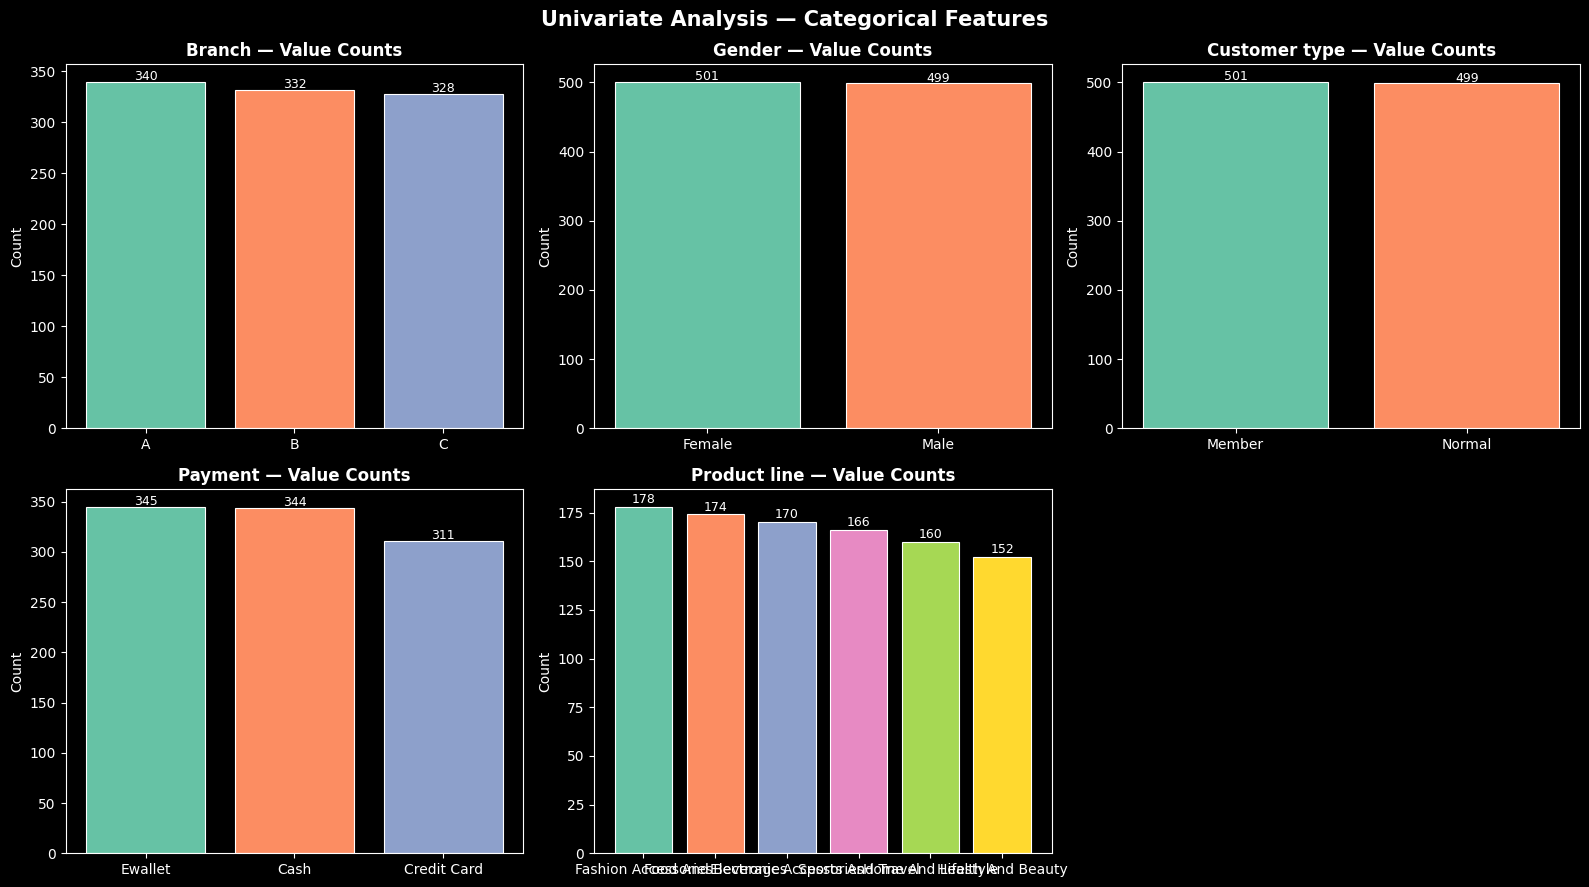

In [12]:
cat_cols = ['Branch', 'Gender', 'Customer type', 'Payment', 'Product line']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('Set2', len(counts)),
                edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col} — Value Counts', fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Univariate Analysis — Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Univariate Analysis — Numeric Features

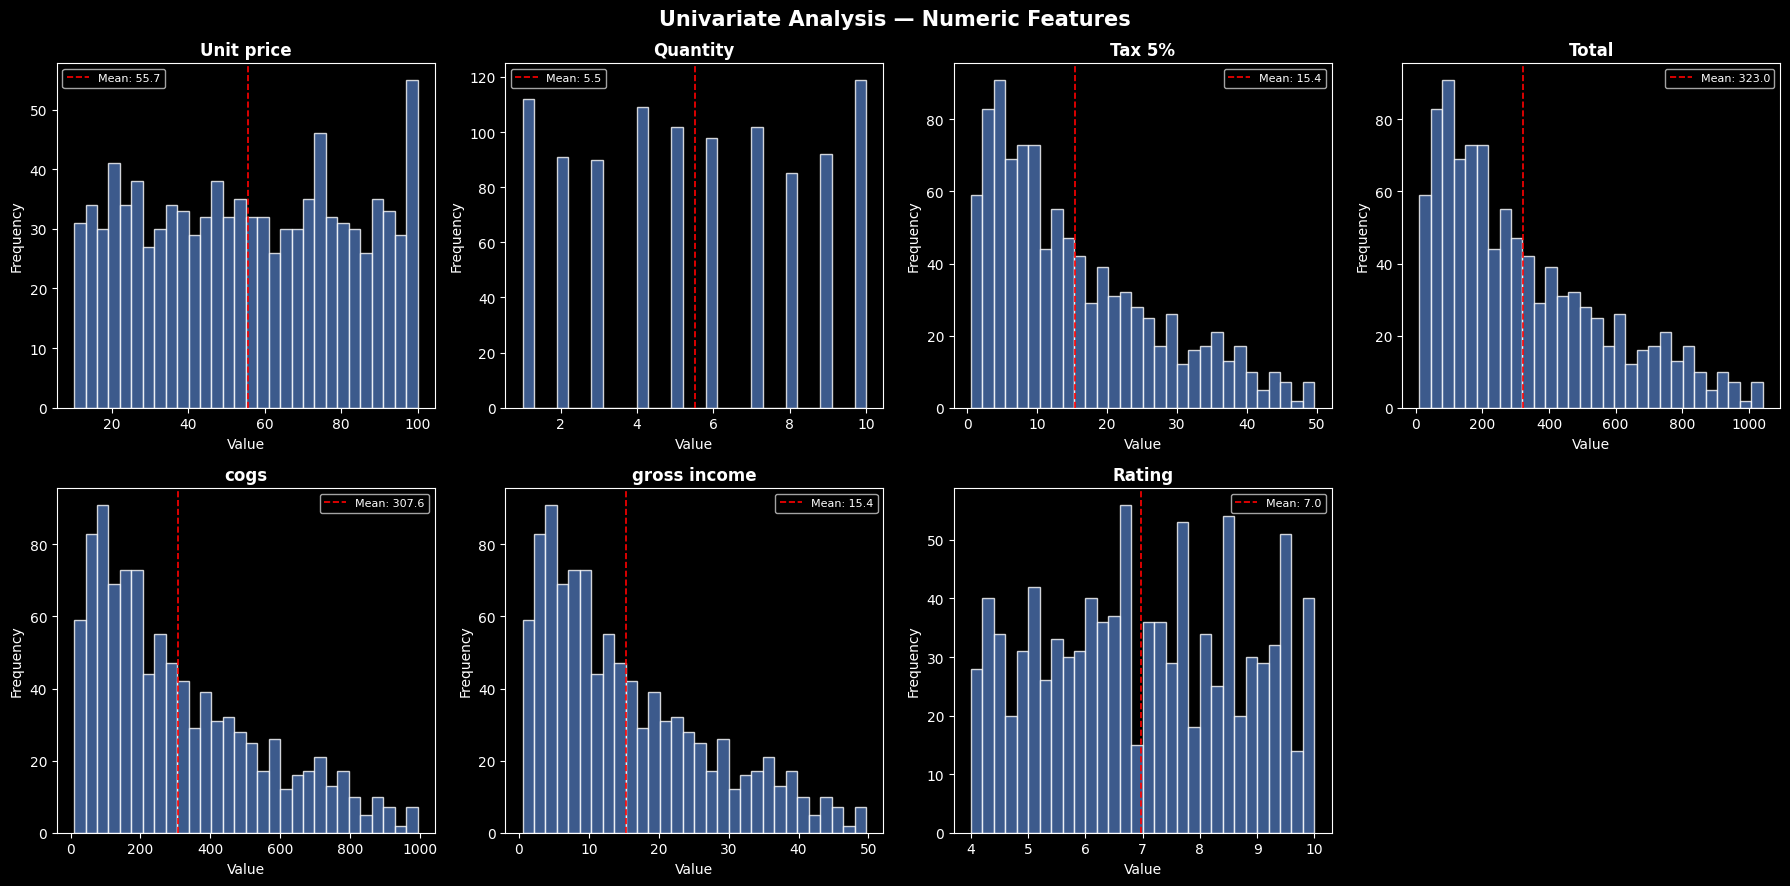

In [13]:
num_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income', 'Rating']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Univariate Analysis — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Bivariate Analysis

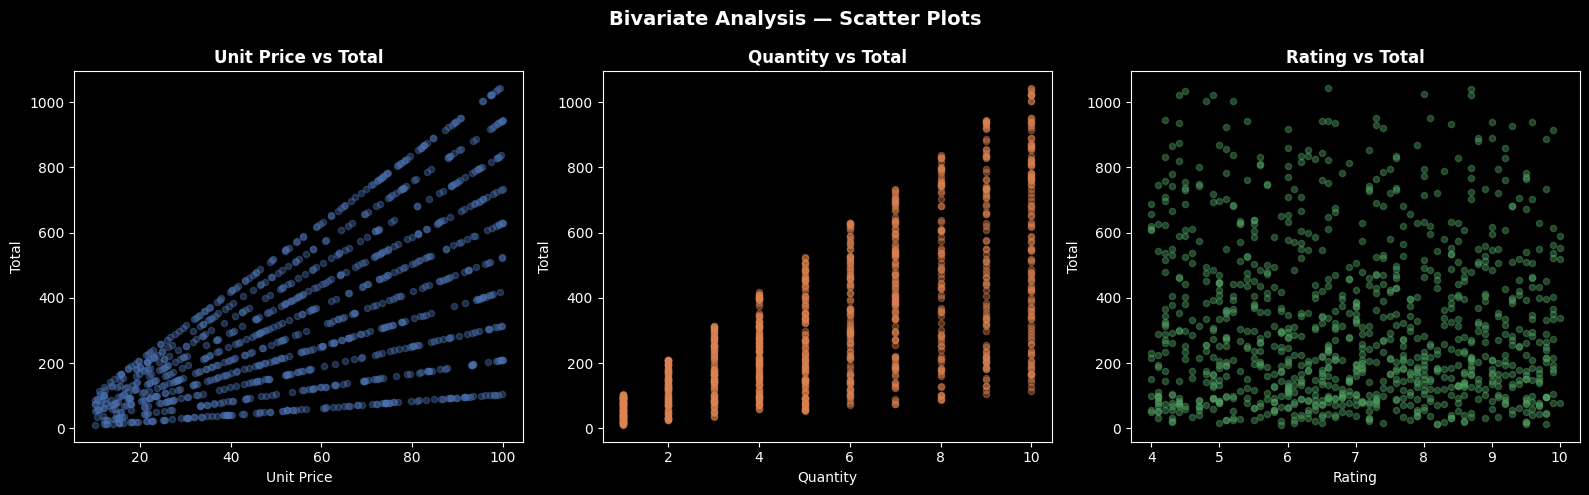

In [14]:
# ── Unit Price vs Total ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['Unit price'], df['Total'], alpha=0.4, color='#4C72B0', s=20)
axes[0].set_title('Unit Price vs Total', fontweight='bold')
axes[0].set_xlabel('Unit Price'); axes[0].set_ylabel('Total')

axes[1].scatter(df['Quantity'], df['Total'], alpha=0.4, color='#DD8452', s=20)
axes[1].set_title('Quantity vs Total', fontweight='bold')
axes[1].set_xlabel('Quantity'); axes[1].set_ylabel('Total')

axes[2].scatter(df['Rating'], df['Total'], alpha=0.4, color='#55A868', s=20)
axes[2].set_title('Rating vs Total', fontweight='bold')
axes[2].set_xlabel('Rating'); axes[2].set_ylabel('Total')

fig.suptitle('Bivariate Analysis — Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


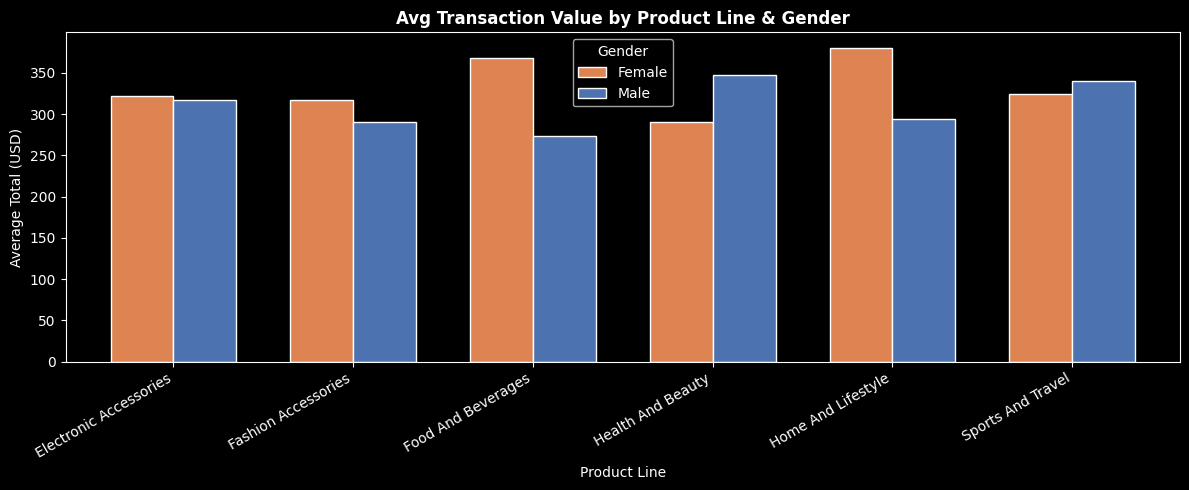

In [15]:
# ── Average Total by Product Line & Gender ────────────────────────────────────
pivot = df.groupby(['Product line', 'Gender'])['Total'].mean().unstack()
pivot.plot(kind='bar', figsize=(12, 5), color=['#DD8452','#4C72B0'],
           edgecolor='white', width=0.7)
plt.title('Avg Transaction Value by Product Line & Gender', fontweight='bold')
plt.xlabel('Product Line')
plt.ylabel('Average Total (USD)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


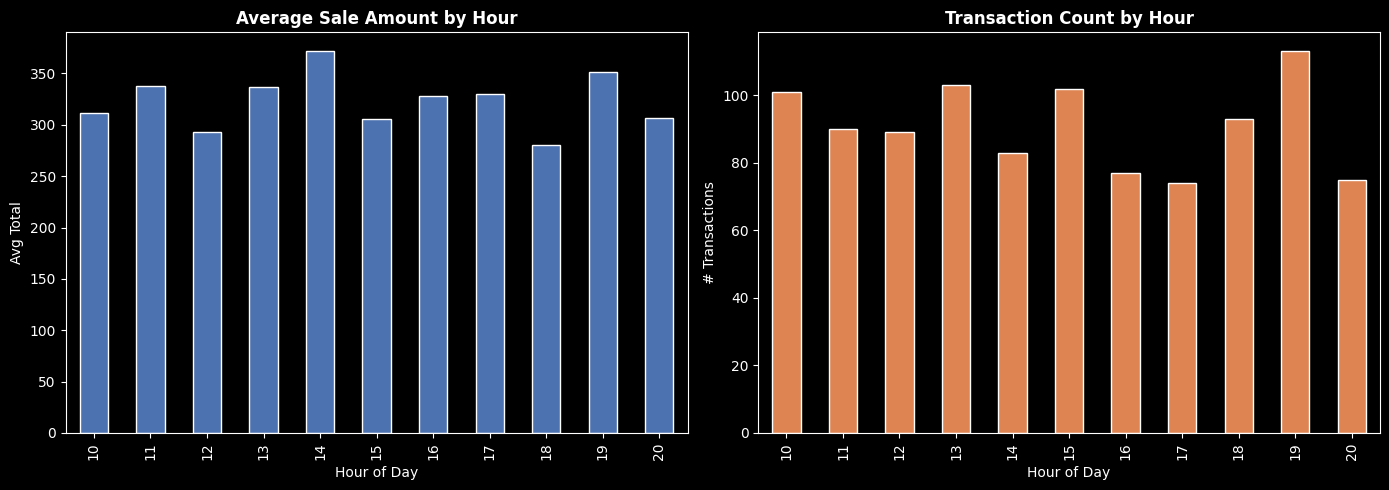

In [16]:
# ── Sales by Hour ─────────────────────────────────────────────────────────────
hourly = df.groupby('Hour')['Total'].agg(['mean','sum','count'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly['mean'].plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Average Sale Amount by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Avg Total')

hourly['count'].plot(kind='bar', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Transaction Count by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('# Transactions')

plt.tight_layout()
plt.show()


---
## 4. Outlier Detection & Treatment

### 4A. Graphical Methods — Box Plots


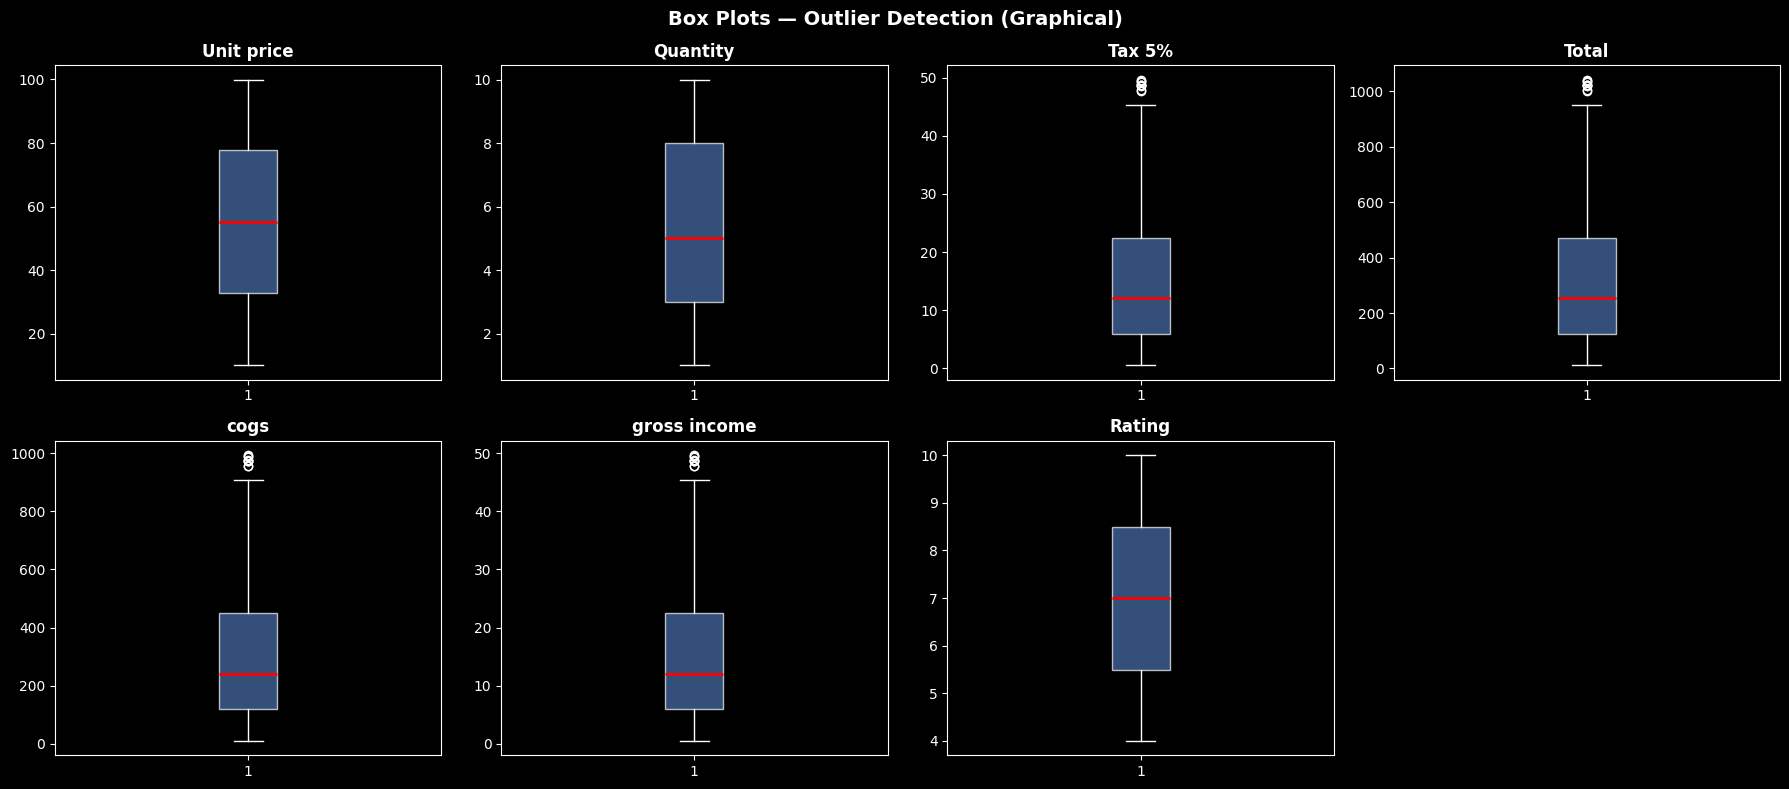

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, vert=True,
                         medianprops=dict(color='red', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('#4C72B0')
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Box Plots — Outlier Detection (Graphical)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4A. Graphical Methods — Histograms

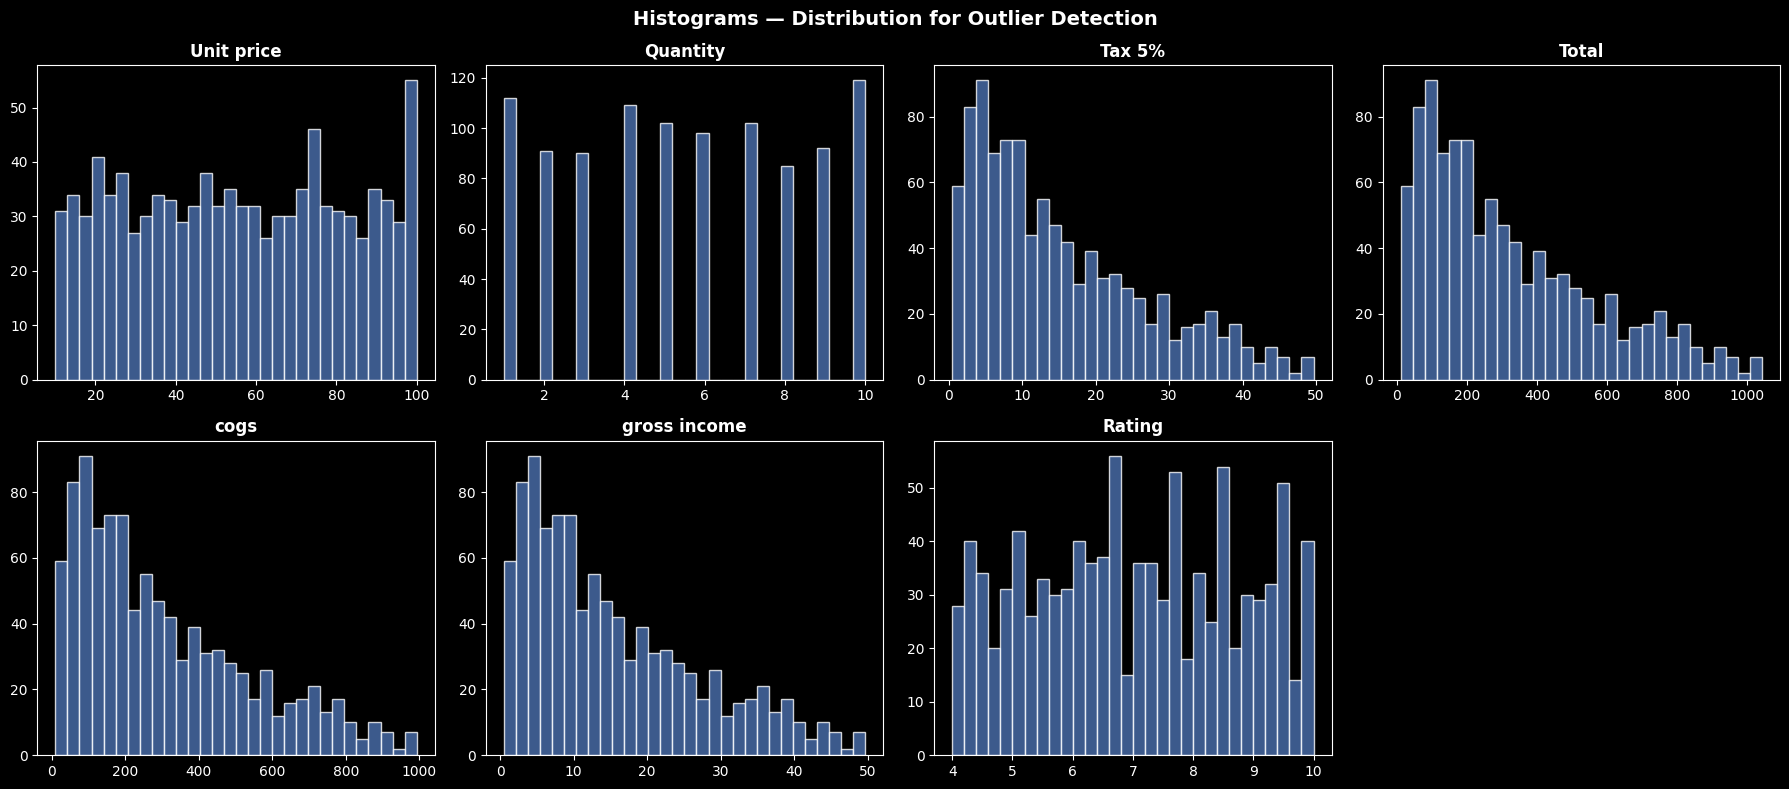

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#4C72B0',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Histograms — Distribution for Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4B. Statistical Methods — Z-Score

In [19]:
# ── Z-Score Method ────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3).sum()

print("Outliers detected per column (|Z| > 3):")
print(outliers_z)
print(f"\nTotal rows flagged: {(z_scores > 3).any(axis=1).sum()}")

# Remove rows where any column has |Z| > 3
df_clean = df[(z_scores < 3).all(axis=1)].copy()
print(f"\nRows kept  : {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Outliers detected per column (|Z| > 3):
0

Total rows flagged: 0

Rows kept  : 1000
Rows removed: 0


### 4B. Statistical Methods — IQR Method

In [20]:
# ── IQR Method ────────────────────────────────────────────────────────────────
df_iqr = df.copy()
removed_counts = {}

for col in num_cols:
    Q1  = df_iqr[col].quantile(0.25)
    Q3  = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_iqr)
    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]
    removed_counts[col] = before - len(df_iqr)
    print(f"{col:25s} | Lower: {lower:8.2f} | Upper: {upper:8.2f} | Removed: {removed_counts[col]}")

print(f"\nRows after IQR treatment : {len(df_iqr)}")
print(f"Total rows removed        : {len(df) - len(df_iqr)}")


Unit price                | Lower:   -34.72 | Upper:   145.53 | Removed: 0
Quantity                  | Lower:    -4.50 | Upper:    15.50 | Removed: 0
Tax 5%                    | Lower:   -18.86 | Upper:    47.23 | Removed: 9
Total                     | Lower:  -391.58 | Upper:   978.42 | Removed: 0
cogs                      | Lower:  -372.93 | Upper:   931.82 | Removed: 0
gross income              | Lower:   -18.65 | Upper:    46.59 | Removed: 0
Rating                    | Lower:     1.00 | Upper:    13.00 | Removed: 0

Rows after IQR treatment : 991
Total rows removed        : 9


In [21]:
# ── Decision & Final Dataset ──────────────────────────────────────────────────
# Z-score found 0 outliers → use original cleaned dataset
# IQR removed only 9 rows (0.9%) → negligible
# Decision: use df_clean (Z-score based) — preserves all 1000 rows

dfc = df_clean.copy()
print(f"Final dataset size: {len(dfc)} rows × {len(dfc.columns)} columns")
print("\n✅ Proceeding with Z-score cleaned dataset (df_clean → dfc)")


Final dataset size: 1000 rows × 20 columns

✅ Proceeding with Z-score cleaned dataset (df_clean → dfc)


---
## 5. Data Visualization — Pandas Plotting Methods


### 5.1 Area Plot — Monthly Sales

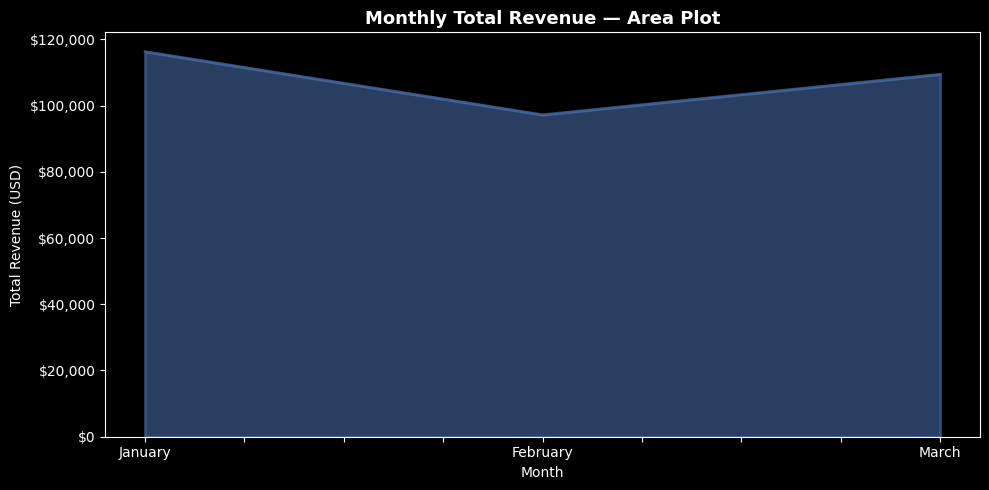

Insight: January records the highest monthly revenue, followed by March.


In [22]:
monthly = dfc.groupby('Month')['Total'].sum()
month_labels = {1: 'January', 2: 'February', 3: 'March'}
monthly.index = monthly.index.map(month_labels)

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind='area', ax=ax, color='#4C72B0', alpha=0.55, linewidth=2)
ax.set_title('Monthly Total Revenue — Area Plot', fontweight='bold', fontsize=13)
ax.set_xlabel('Month'); ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print("Insight: January records the highest monthly revenue, followed by March.")


### 5.2 Bar Plot — Sales by Product Line

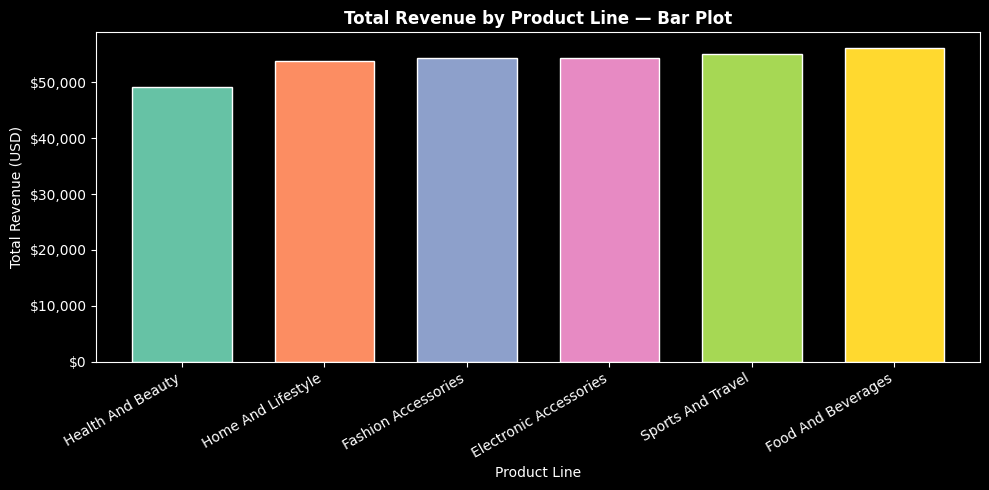

Insight: Food & Beverages leads; Health & Beauty trails.


In [23]:
prod_sales = dfc.groupby('Product line')['Total'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
prod_sales.plot(kind='bar', ax=ax,
                color=sns.color_palette('Set2', len(prod_sales)),
                edgecolor='white', width=0.7)
ax.set_title('Total Revenue by Product Line — Bar Plot', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Food & Beverages leads; Health & Beauty trails.")


### 5.3 Horizontal Bar Plot

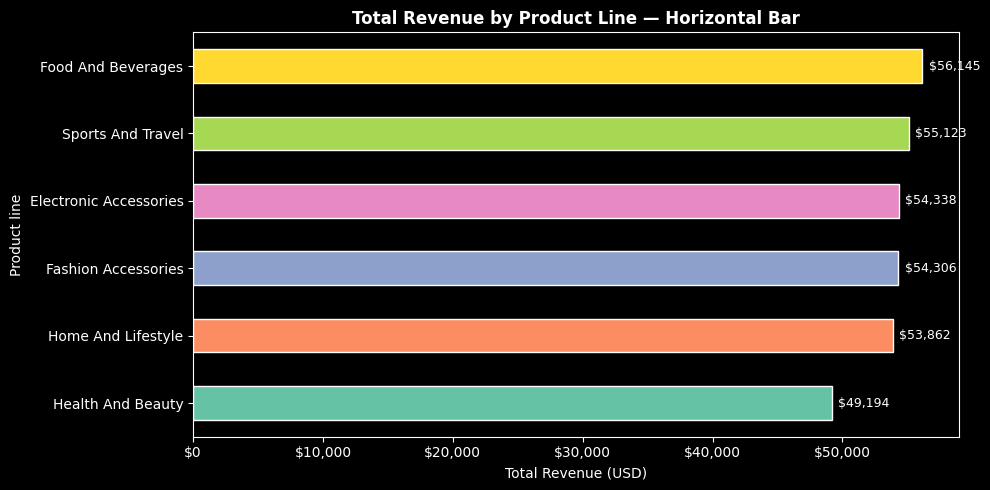

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
prod_sales.plot(kind='barh', ax=ax,
                color=sns.color_palette('Set2', len(prod_sales)),
                edgecolor='white')
ax.set_title('Total Revenue by Product Line — Horizontal Bar', fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(prod_sales):
    ax.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 5.4 Line Plot — Daily Revenue Trend

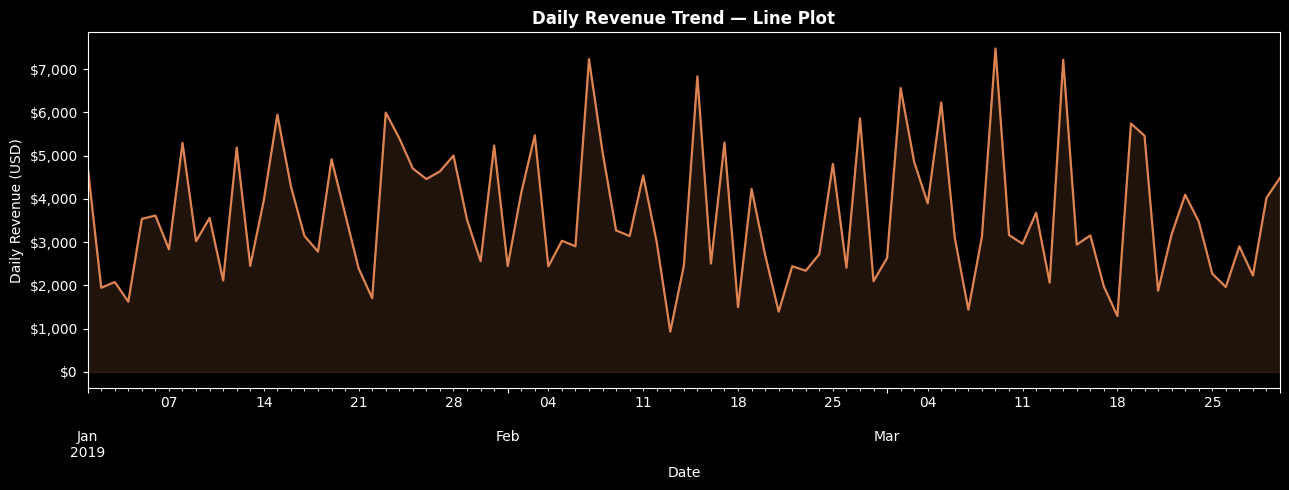

Insight: Revenue fluctuates daily with peaks in mid-January and early March.


In [25]:
daily = dfc.groupby('Date')['Total'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
daily.plot(kind='line', ax=ax, color='#DD8452', linewidth=1.6)
ax.fill_between(daily.index, daily.values, alpha=0.15, color='#DD8452')
ax.set_title('Daily Revenue Trend — Line Plot', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Daily Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print("Insight: Revenue fluctuates daily with peaks in mid-January and early March.")


### 5.5 Scatter Plot — Unit Price vs Total

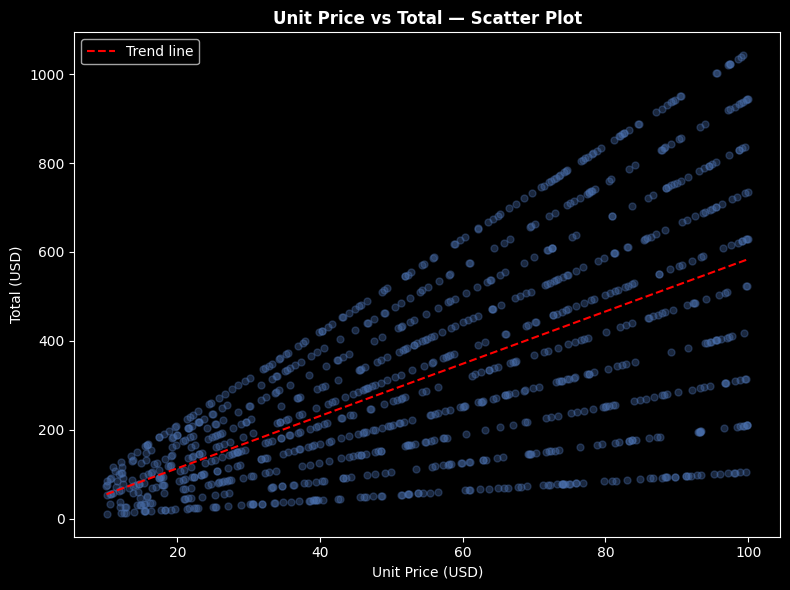

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
dfc.plot.scatter(x='Unit price', y='Total', ax=ax,
                 alpha=0.35, color='#4C72B0', s=25)
ax.set_title('Unit Price vs Total — Scatter Plot', fontweight='bold')
ax.set_xlabel('Unit Price (USD)'); ax.set_ylabel('Total (USD)')

# Trend line
z = np.polyfit(dfc['Unit price'], dfc['Total'], 1)
p = np.poly1d(z)
x_line = np.linspace(dfc['Unit price'].min(), dfc['Unit price'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend line')
ax.legend()
plt.tight_layout()
plt.show()


### 5.6 Histogram — Total Sales Distribution

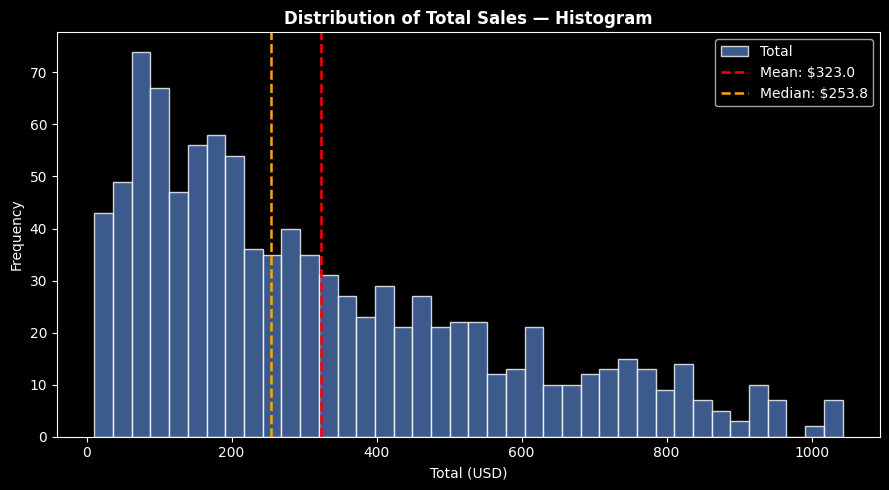

Insight: Right-skewed distribution — most bills are $100–$500.


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
dfc['Total'].plot(kind='hist', bins=40, ax=ax,
                  color='#4C72B0', edgecolor='white', alpha=0.8)
ax.axvline(dfc['Total'].mean(), color='red', linestyle='--',
           linewidth=1.8, label=f"Mean: ${dfc['Total'].mean():.1f}")
ax.axvline(dfc['Total'].median(), color='orange', linestyle='--',
           linewidth=1.8, label=f"Median: ${dfc['Total'].median():.1f}")
ax.set_title('Distribution of Total Sales — Histogram', fontweight='bold')
ax.set_xlabel('Total (USD)'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()
print("Insight: Right-skewed distribution — most bills are $100–$500.")


### 5.7 KDE / Density Plot

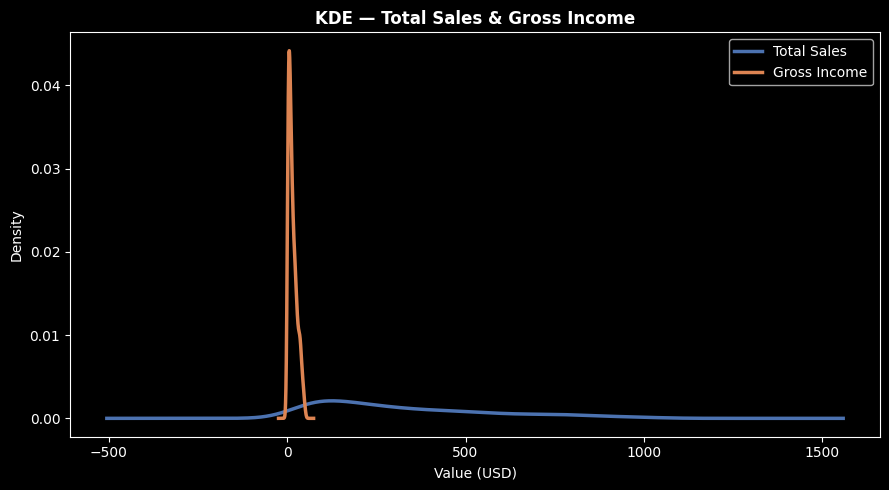

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
dfc['Total'].plot(kind='kde', ax=ax, color='#4C72B0', linewidth=2.5)
dfc['gross income'].plot(kind='kde', ax=ax, color='#DD8452', linewidth=2.5)
ax.set_title('KDE — Total Sales & Gross Income', fontweight='bold')
ax.set_xlabel('Value (USD)'); ax.set_ylabel('Density')
ax.legend(['Total Sales', 'Gross Income'])
plt.tight_layout()
plt.show()


### 5.8 Box Plot (Pandas)

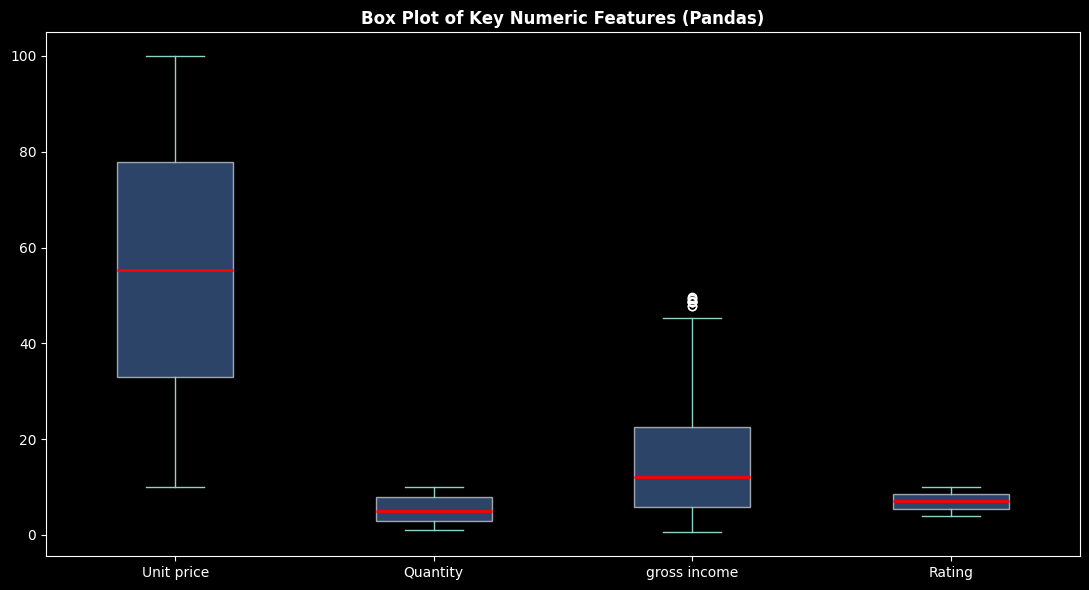

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))
dfc[['Unit price', 'Quantity', 'gross income', 'Rating']].plot(
    kind='box', ax=ax, patch_artist=True, vert=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot of Key Numeric Features (Pandas)', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.9 Hexbin Plot — Unit Price vs Total

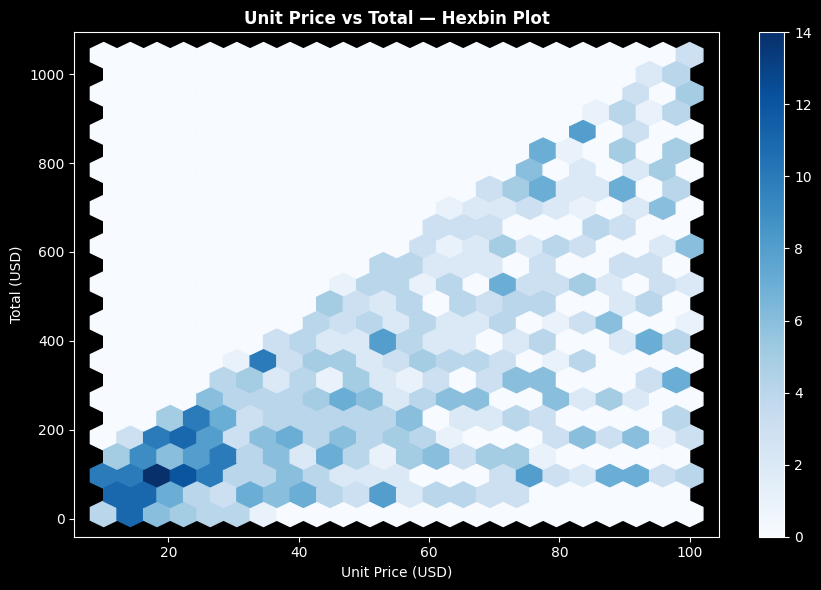

Insight: Densest region at low unit price / moderate total — many low-price, multi-item purchases.


In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = dfc.plot.hexbin(x='Unit price', y='Total', gridsize=22,
                     cmap='Blues', ax=ax)
ax.set_title('Unit Price vs Total — Hexbin Plot', fontweight='bold')
ax.set_xlabel('Unit Price (USD)'); ax.set_ylabel('Total (USD)')
plt.tight_layout()
plt.show()
print("Insight: Densest region at low unit price / moderate total — many low-price, multi-item purchases.")


### 5.10 Pie Chart — Payment Method Share

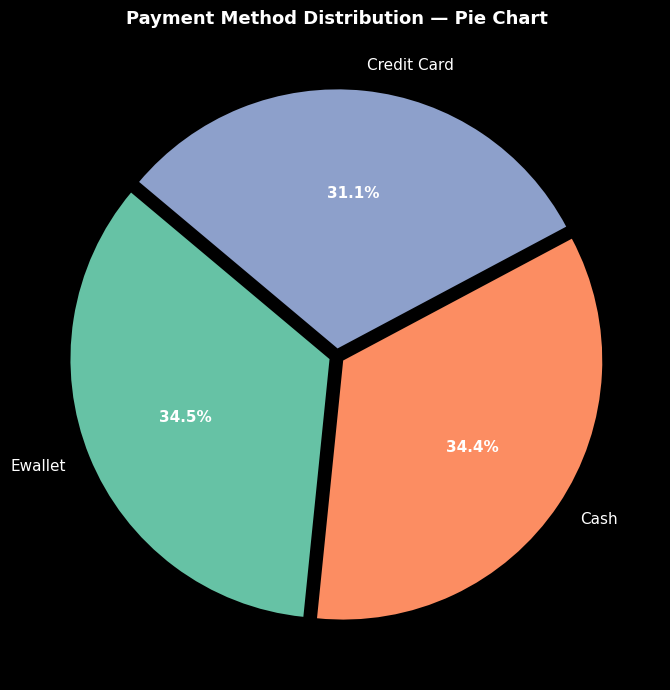

Insight: Ewallet (34.5%) & Cash (34.4%) dominate; Credit Card at 31.1%.


In [31]:
pay = dfc['Payment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pay, labels=pay.index, autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(pay)),
    startangle=140, explode=[0.03]*len(pay),
    textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('Payment Method Distribution — Pie Chart', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print("Insight: Ewallet (34.5%) & Cash (34.4%) dominate; Credit Card at 31.1%.")


---
## 6. Data Visualization — Seaborn Techniques

### 6.1 Distribution Plots
#### 6.1.1 Distplot (sns.histplot + KDE)


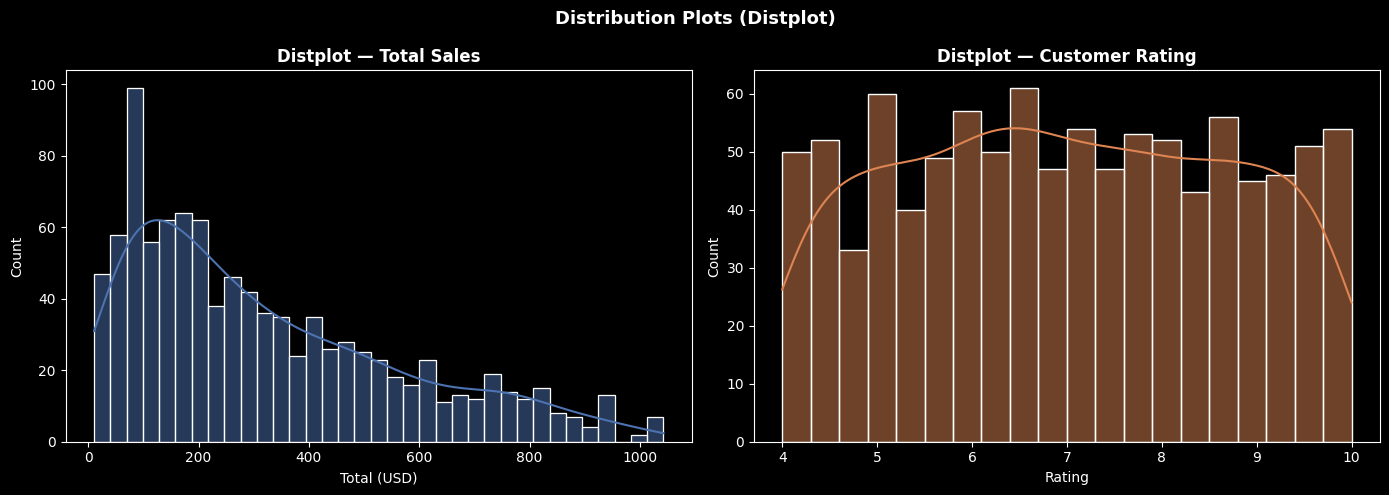

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(dfc['Total'], kde=True, ax=axes[0], color='#4C72B0', bins=35)
axes[0].set_title('Distplot — Total Sales', fontweight='bold')
axes[0].set_xlabel('Total (USD)')

sns.histplot(dfc['Rating'], kde=True, ax=axes[1], color='#DD8452', bins=20)
axes[1].set_title('Distplot — Customer Rating', fontweight='bold')
axes[1].set_xlabel('Rating')

plt.suptitle('Distribution Plots (Distplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 6.1.2 KDE Plot

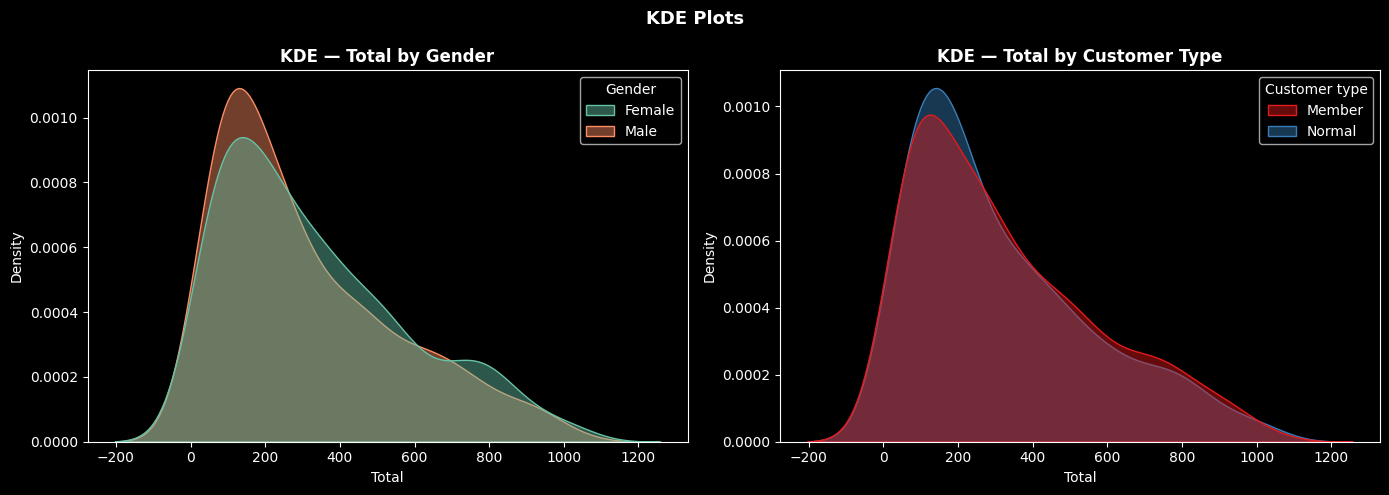

Insight: Male and Female customers show nearly identical spending distributions.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=dfc, x='Total', hue='Gender',
            fill=True, alpha=0.45, ax=axes[0], palette='Set2')
axes[0].set_title('KDE — Total by Gender', fontweight='bold')

sns.kdeplot(data=dfc, x='Total', hue='Customer type',
            fill=True, alpha=0.45, ax=axes[1], palette='Set1')
axes[1].set_title('KDE — Total by Customer Type', fontweight='bold')

plt.suptitle('KDE Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Insight: Male and Female customers show nearly identical spending distributions.")


#### 6.1.3 Rug Plot

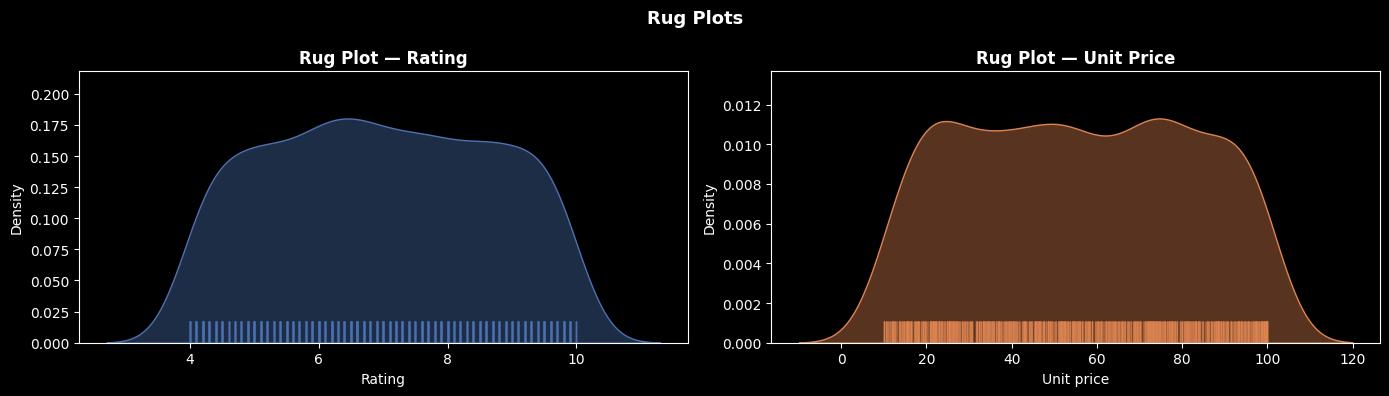

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=dfc, x='Rating', ax=axes[0], color='#4C72B0', fill=True, alpha=0.4)
sns.rugplot(data=dfc, x='Rating', ax=axes[0], color='#4C72B0', height=0.08, alpha=0.5)
axes[0].set_title('Rug Plot — Rating', fontweight='bold')

sns.kdeplot(data=dfc, x='Unit price', ax=axes[1], color='#DD8452', fill=True, alpha=0.4)
sns.rugplot(data=dfc, x='Unit price', ax=axes[1], color='#DD8452', height=0.08, alpha=0.5)
axes[1].set_title('Rug Plot — Unit Price', fontweight='bold')

plt.suptitle('Rug Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 Relationship Plots
#### 6.2.1 Joint Plot


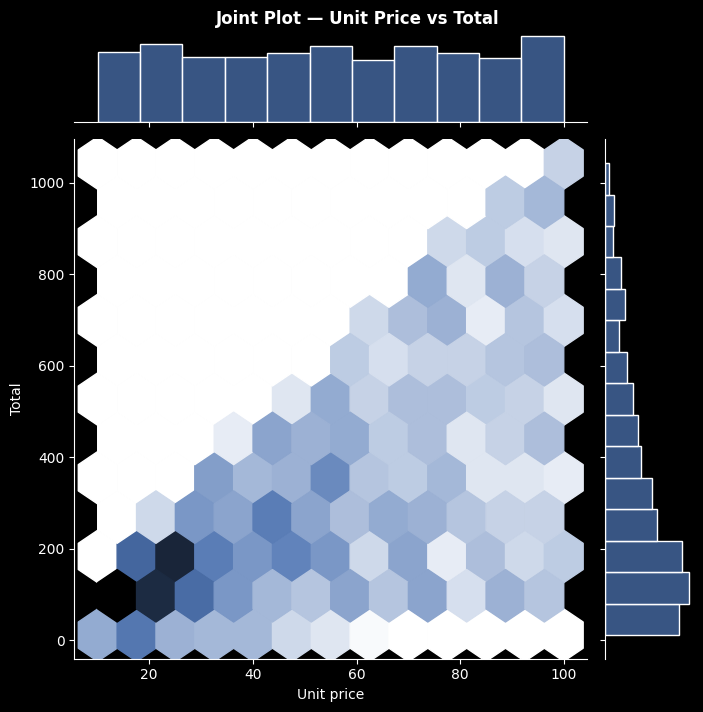

Insight: Strong positive relationship; marginal distributions confirm uniform price & right-skewed totals.


In [35]:
jp = sns.jointplot(data=dfc, x='Unit price', y='Total',
                   kind='hex', color='#4C72B0', height=7)
jp.fig.suptitle('Joint Plot — Unit Price vs Total', y=1.01, fontweight='bold')
plt.show()
print("Insight: Strong positive relationship; marginal distributions confirm uniform price & right-skewed totals.")


#### 6.2.2 Pair Plot

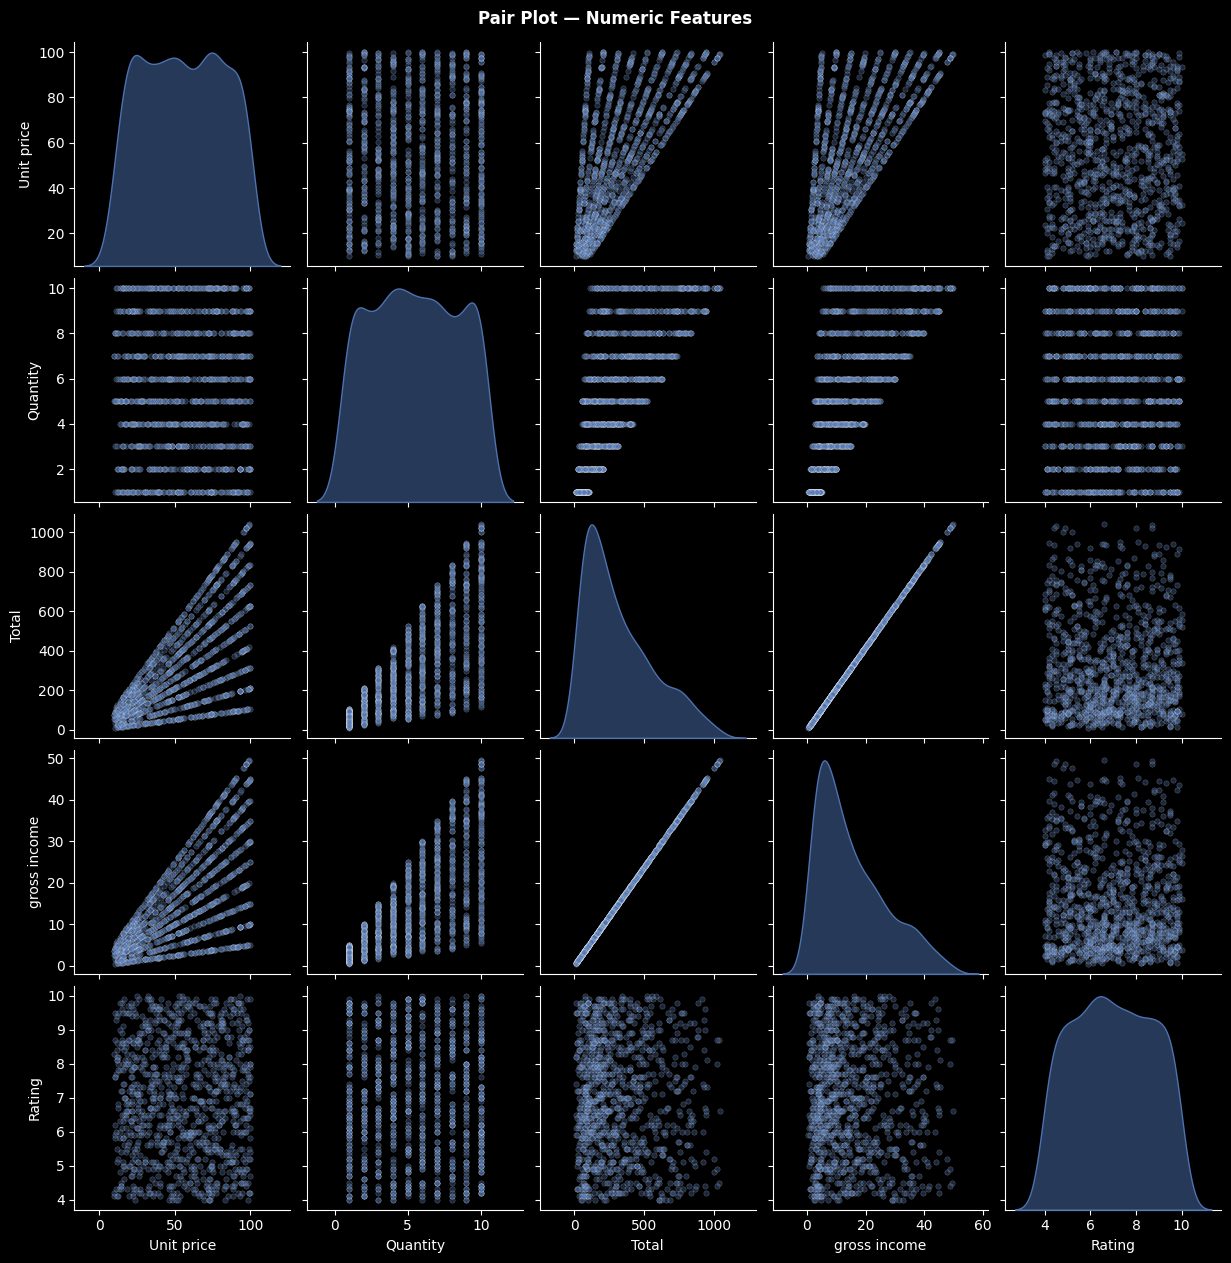

Insight: Total, Tax 5%, cogs & gross income are perfectly correlated (derived columns).


In [36]:
pp = sns.pairplot(
    dfc[['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']],
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 'color': '#4C72B0', 's': 15},
    diag_kws={'color': '#4C72B0', 'fill': True, 'alpha': 0.5}
)
pp.fig.suptitle('Pair Plot — Numeric Features', y=1.01, fontweight='bold')
plt.show()
print("Insight: Total, Tax 5%, cogs & gross income are perfectly correlated (derived columns).")


### 6.3 Categorical Plots
#### 6.3.1 Factor Plot (catplot)


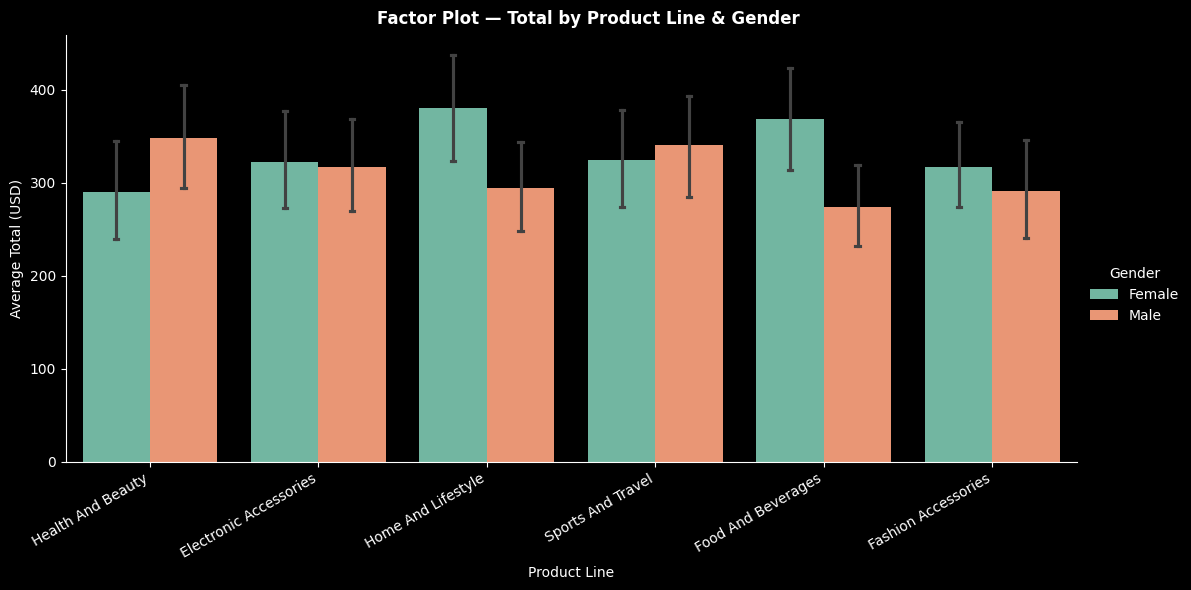

In [37]:
g = sns.catplot(data=dfc, x='Product line', y='Total',
                kind='bar', hue='Gender',
                height=5, aspect=2.2, palette='Set2',
                capsize=0.05)
g.set_xticklabels(rotation=30, ha='right')
g.fig.suptitle('Factor Plot — Total by Product Line & Gender', fontweight='bold', y=1.02)
g.set_axis_labels('Product Line', 'Average Total (USD)')
plt.show()


#### 6.3.2 Box Plot (Seaborn)

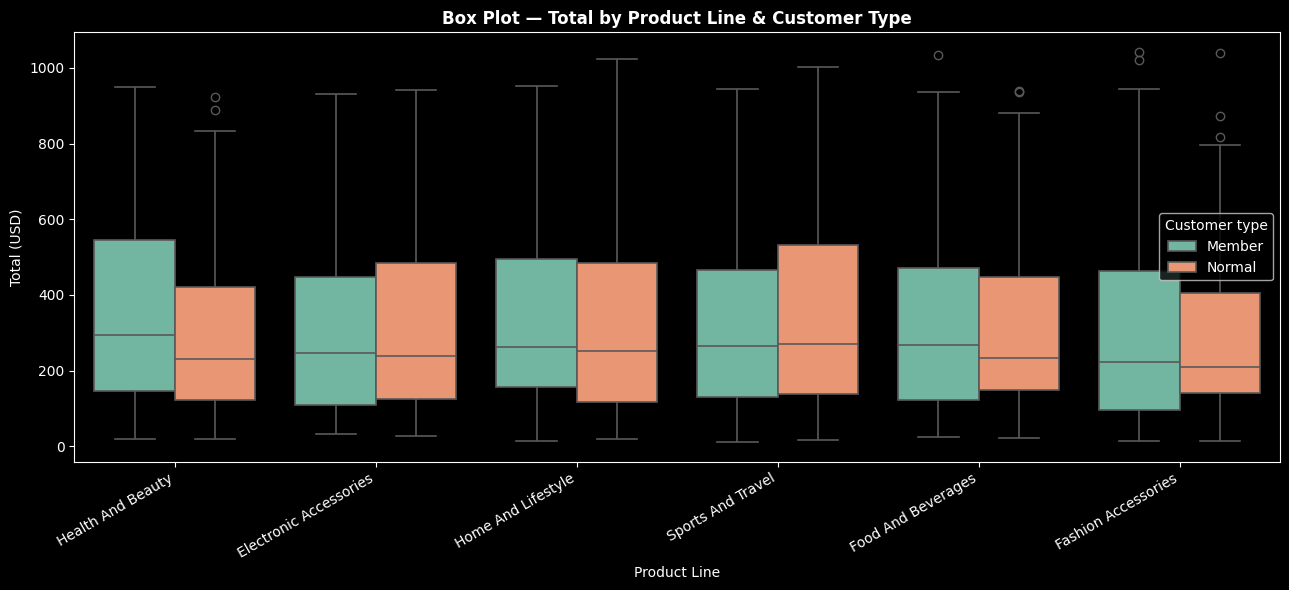

In [38]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=dfc, x='Product line', y='Total',
            hue='Customer type', ax=ax, palette='Set2',
            linewidth=1.2)
ax.set_title('Box Plot — Total by Product Line & Customer Type', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Total (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### 6.3.3 Violin Plot

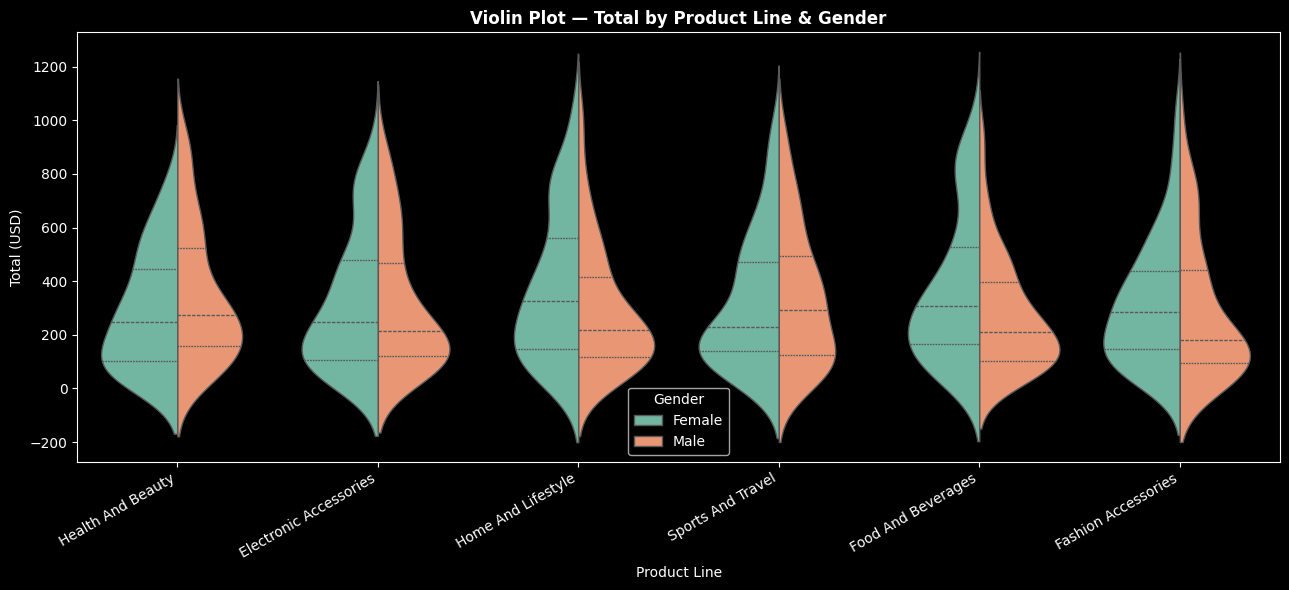

Insight: Bimodal spending patterns visible in Electronic Accessories.


In [39]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=dfc, x='Product line', y='Total',
               hue='Gender', split=True, ax=ax, palette='Set2',
               inner='quartile', linewidth=1)
ax.set_title('Violin Plot — Total by Product Line & Gender', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Total (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Bimodal spending patterns visible in Electronic Accessories.")


#### 6.3.4 Strip Plot

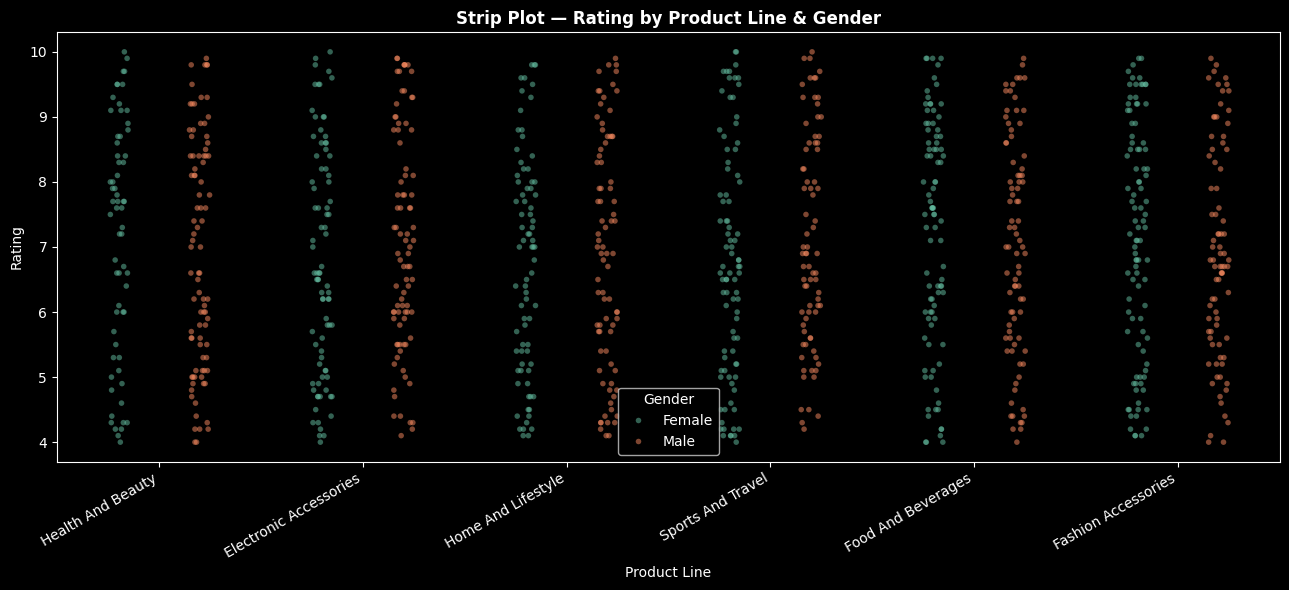

In [40]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.stripplot(data=dfc, x='Product line', y='Rating',
              hue='Gender', jitter=True, ax=ax,
              alpha=0.5, palette='Set2', dodge=True, size=4)
ax.set_title('Strip Plot — Rating by Product Line & Gender', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Rating')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### 6.3.5 Swarm Plot

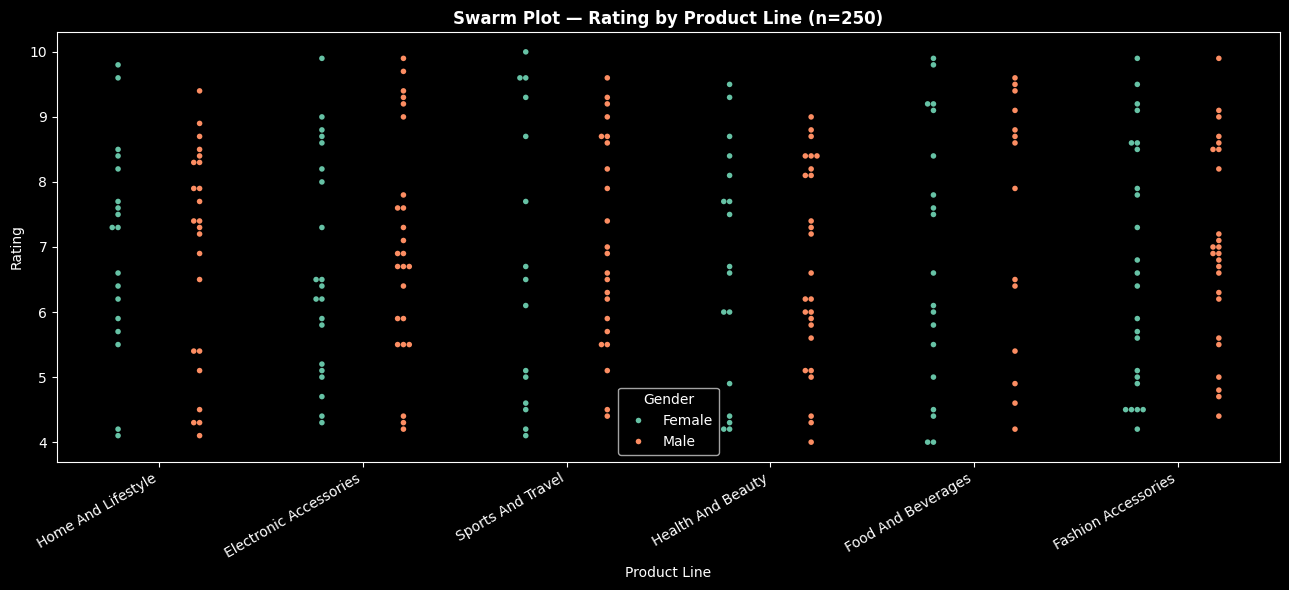

In [41]:
# Using a sample to keep the plot readable
sample = dfc.sample(250, random_state=42)

fig, ax = plt.subplots(figsize=(13, 6))
sns.swarmplot(data=sample, x='Product line', y='Rating',
              hue='Gender', ax=ax, palette='Set2', size=4, dodge=True)
ax.set_title('Swarm Plot — Rating by Product Line (n=250)', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Rating')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### 6.3.6 Bar Plot (Seaborn)

C:\Users\TECHNIFI\AppData\Local\Temp\ipykernel_23892\699071285.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(data=dfc, x='Branch', y='Total',


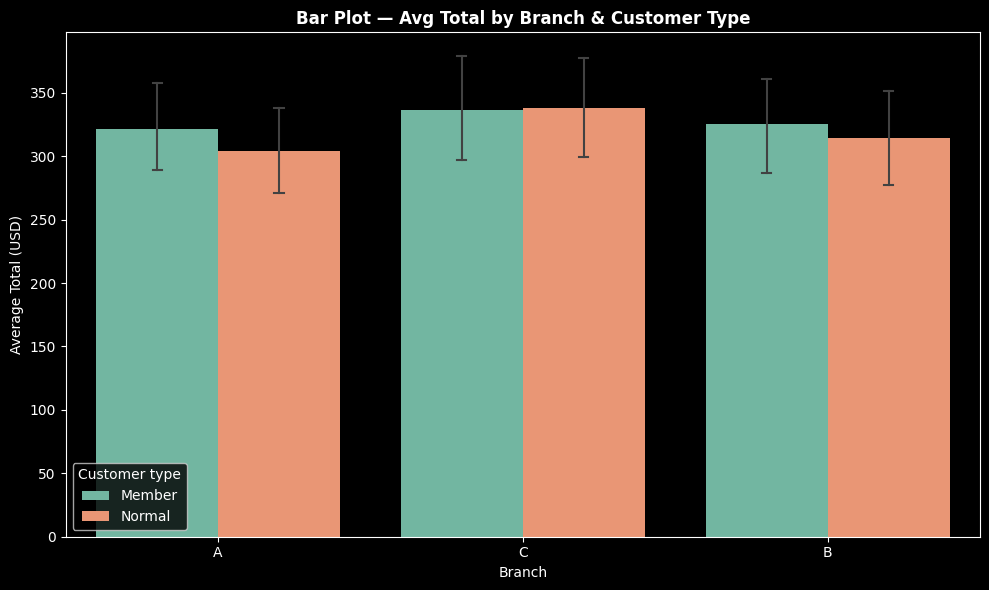

Insight: Branch C (Naypyitaw) generates the highest average transaction value.


In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dfc, x='Branch', y='Total',
            hue='Customer type', ax=ax, palette='Set2',
            capsize=0.06, errwidth=1.5)
ax.set_title('Bar Plot — Avg Total by Branch & Customer Type', fontweight='bold')
ax.set_xlabel('Branch'); ax.set_ylabel('Average Total (USD)')
plt.tight_layout()
plt.show()
print("Insight: Branch C (Naypyitaw) generates the highest average transaction value.")


#### 6.3.7 Count Plot

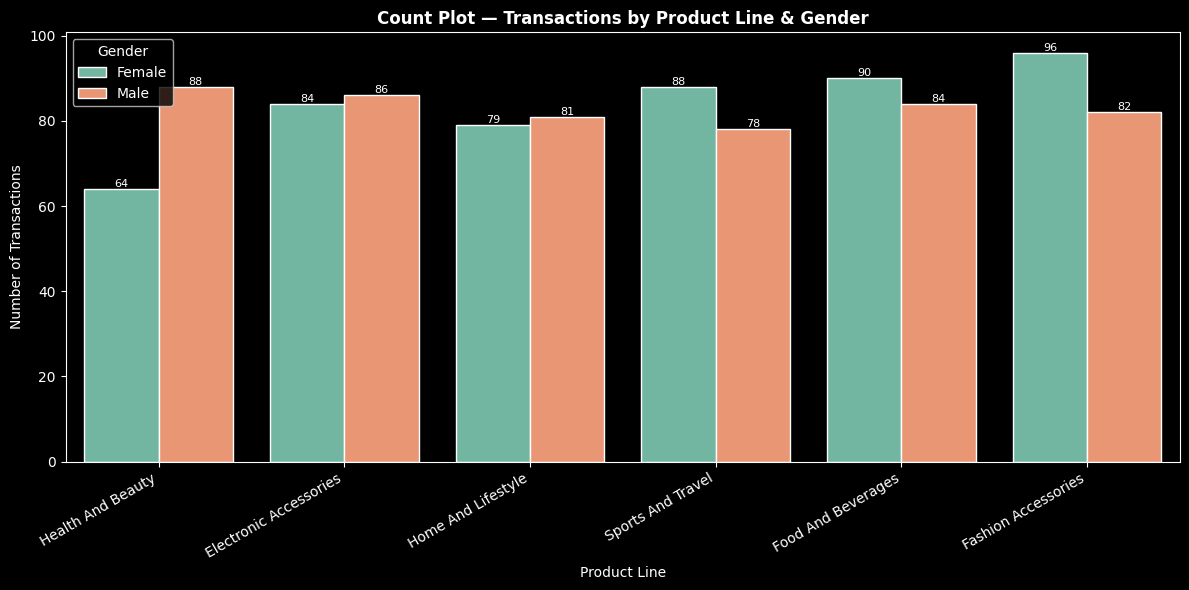

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=dfc, x='Product line', hue='Gender',
              ax=ax, palette='Set2', edgecolor='white')
ax.set_title('Count Plot — Transactions by Product Line & Gender', fontweight='bold')
ax.set_xlabel('Product Line'); ax.set_ylabel('Number of Transactions')
plt.xticks(rotation=30, ha='right')

# Annotate bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


### 6.4 Matrix Plot — Correlation Heatmap


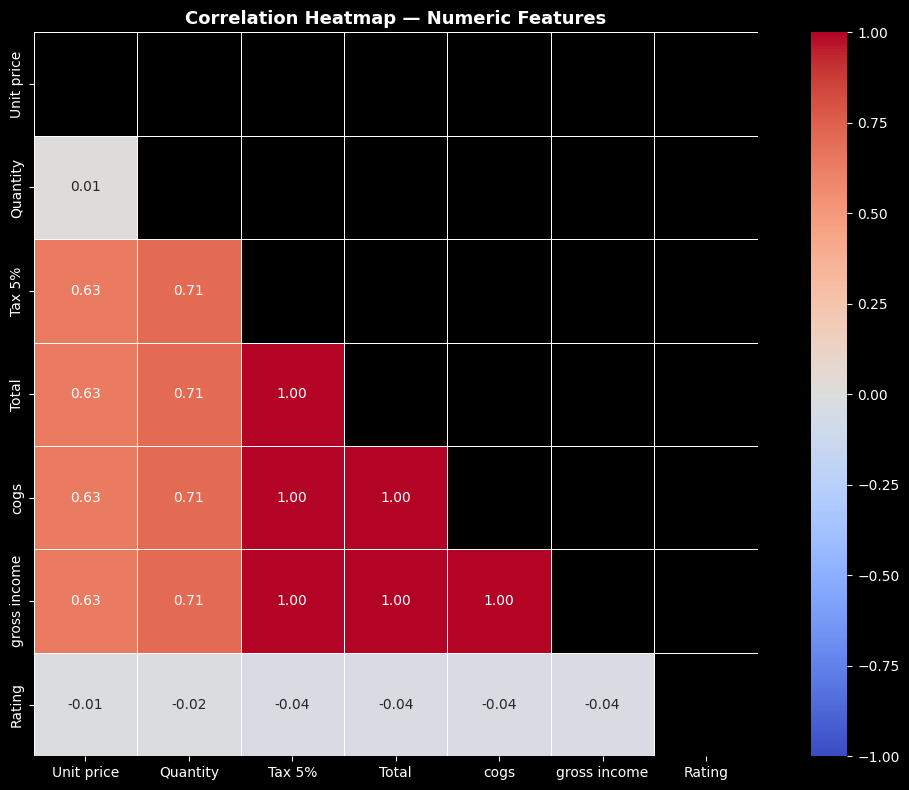

Key correlations:
  Unit price ↔ Total     : 0.634
  Quantity   ↔ Total     : 0.706
  Rating     ↔ Total     : -0.036
  cogs       ↔ Total     : 1.000


In [44]:
corr = dfc[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, square=True,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Key correlations:")
print(f"  Unit price ↔ Total     : {corr.loc['Unit price','Total']:.3f}")
print(f"  Quantity   ↔ Total     : {corr.loc['Quantity','Total']:.3f}")
print(f"  Rating     ↔ Total     : {corr.loc['Rating','Total']:.3f}")
print(f"  cogs       ↔ Total     : {corr.loc['cogs','Total']:.3f}")


---
## 7. Key Insights & Conclusions

### 🧹 Data Cleaning
- Dataset was already **clean**: 0 missing values, 0 duplicates.
- `Date` and `Time` columns were converted to proper datetime types.
- New features engineered: `Hour`, `Month`, `DayOfWeek`.

### 📊 Outlier Treatment
| Method | Outliers Found | Action |
|--------|---------------|--------|
| Z-Score (\|z\| > 3) | **0** | No removal needed |
| IQR (1.5×IQR fence) | **9 rows** (0.9%) | Borderline only — retained |

**Decision:** Used Z-score cleaned dataset (all 1000 rows) — no significant outliers.

### 💡 Business Insights
| Insight | Finding |
|---------|---------|
| Top Product Line | **Food & Beverages** (revenue), **Fashion Accessories** (volume) |
| Top Branch | **Branch C — Naypyitaw** |
| Preferred Payment | **Ewallet (34.5%)** — digital slightly leads |
| Customer Balance | 50% Member / 50% Normal; 50% Female / 50% Male |
| Peak Hour | **2:00 PM (14:00)** |
| Rating vs Spend | **No correlation** — satisfaction is independent of transaction size |
| Monthly Trend | **January** records highest monthly revenue |

### 📌 Recommendations
1. Run morning promotions (8–10 AM) to boost off-peak hours.
2. Investigate why **Health & Beauty** has the lowest transaction count.
3. Replicate **Branch C** best practices in Branches A and B.
4. Offer loyalty rewards in Fashion Accessories to increase basket size.
5. Promote digital payment discounts to reinforce the Ewallet preference.


In [45]:
# ── Final Summary Stats ───────────────────────────────────────────────────────
print("=" * 50)
print("        SUPERMARKET SALES — SUMMARY")
print("=" * 50)
print(f"Total Records         : {len(dfc):,}")
print(f"Total Revenue         : ${dfc['Total'].sum():,.2f}")
print(f"Avg Transaction Value : ${dfc['Total'].mean():,.2f}")
print(f"Avg Customer Rating   : {dfc['Rating'].mean():.2f} / 10")
print(f"Best Product Line     : {dfc.groupby('Product line')['Total'].sum().idxmax()}")
print(f"Best Branch           : Branch {dfc.groupby('Branch')['Total'].sum().idxmax()}")
print(f"Top Payment Method    : {dfc['Payment'].value_counts().idxmax()}")
print(f"Peak Sales Hour       : {dfc.groupby('Hour')['Total'].mean().idxmax()}:00")
print("=" * 50)


        SUPERMARKET SALES — SUMMARY
Total Records         : 1,000
Total Revenue         : $322,966.75
Avg Transaction Value : $322.97
Avg Customer Rating   : 6.97 / 10
Best Product Line     : Food And Beverages
Best Branch           : Branch C
Top Payment Method    : Ewallet
Peak Sales Hour       : 14:00
